  Reference Number  Grid Ref: Easting  Grid Ref: Northing  Number of Vehicles  \
0          1112091             429175              431904                   2   
1          1180869             430429              431025                   3   
2          1180869             430429              431025                   3   
3          11A0238             424660              427582                   3   
4          11A0238             424660              427582                   3   

   Number of Casualties Accident Date  Time (24hr)  1st Road Class  \
0                     1    01/01/2014         1840               6   
1                     2    08/01/2014         1430               1   
2                     2    08/01/2014         1430               1   
3                     2    10/01/2014          817               1   
4                     2    10/01/2014          817               1   

   Road Surface  Lighting Conditions  Weather Conditions  Casualty Class  \
0             2 

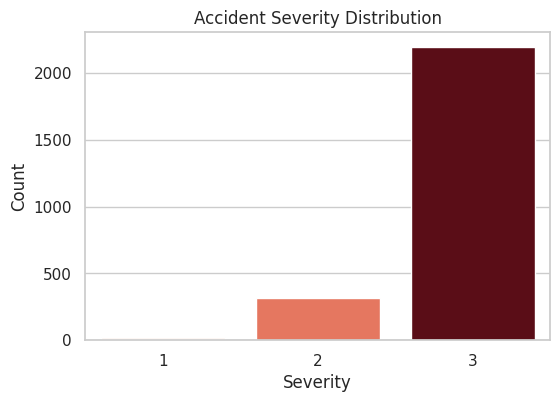

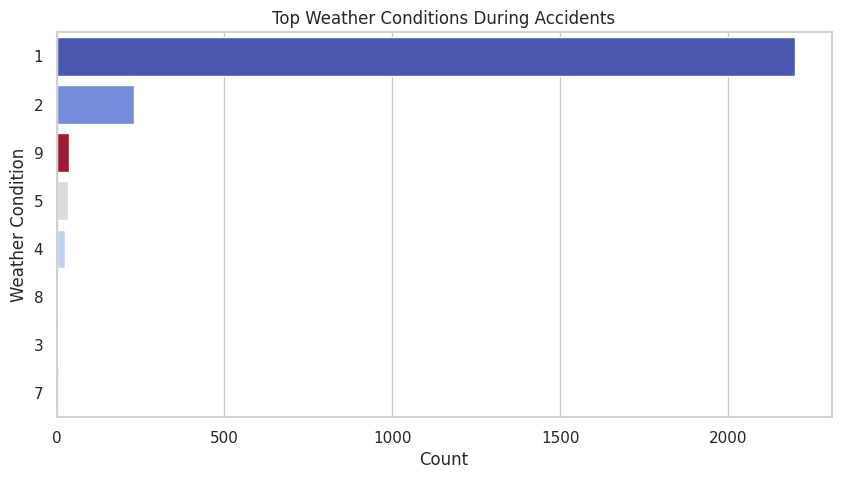

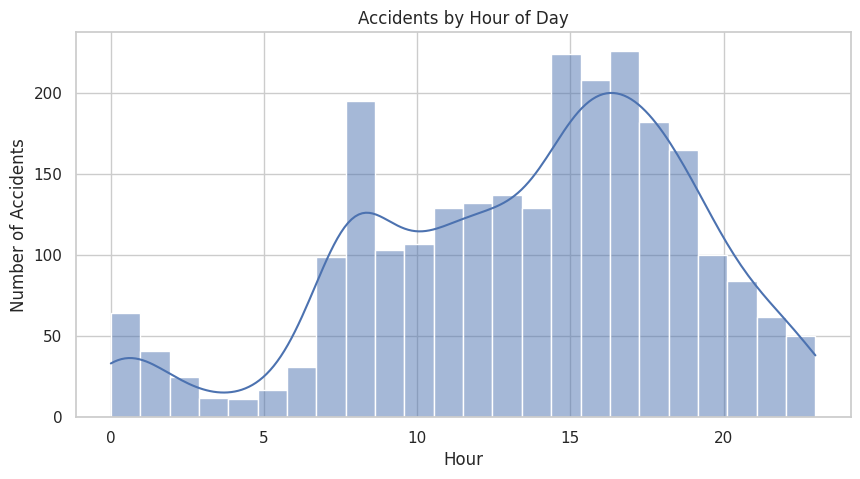

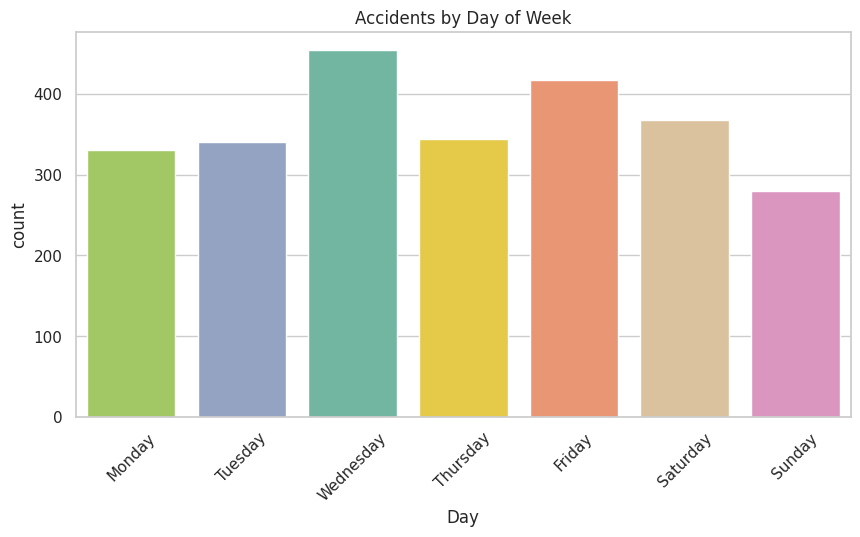

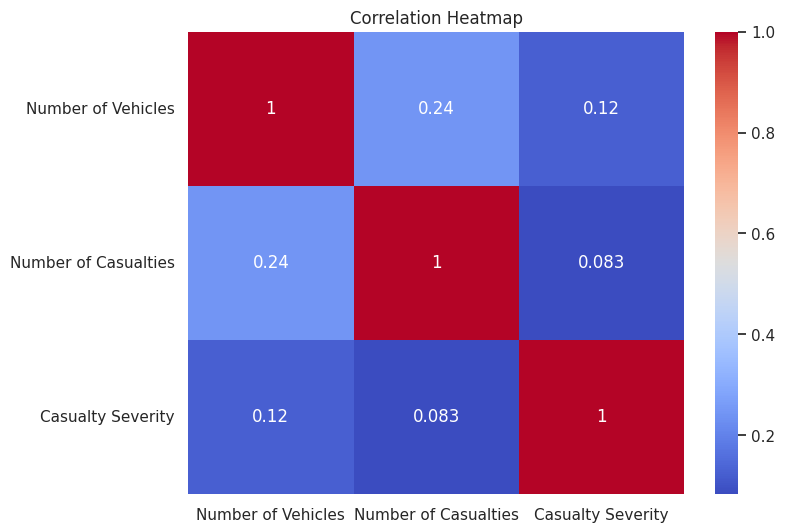

Skipping Accident Hotspots plot due to missing 'Start_Lng' and 'Start_Lat' columns.


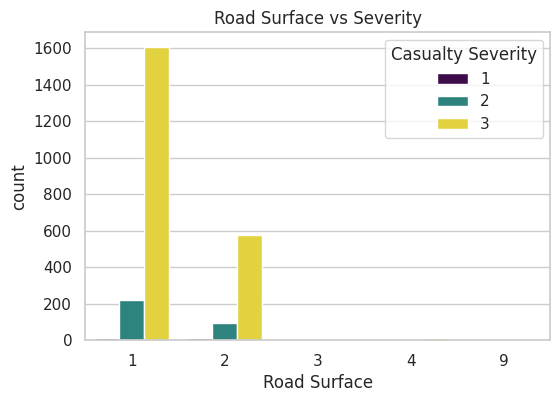

Traffic Accident Data Analysis Completed


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("dataset.csv")

# Show first rows
print(df.head())

# Combine 'Accident Date' and 'Time (24hr)' to create a datetime column
df['DateTime'] = pd.to_datetime(df['Accident Date'] + ' ' + df['Time (24hr)'].astype(str).str.zfill(4), format='%d/%m/%Y %H%M')

# Extract Hour and Day from the new DateTime column
df['Hour'] = df['DateTime'].dt.hour
df['Day'] = df['DateTime'].dt.day_name()

# Set graph style
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x='Casualty Severity', data=df, hue='Casualty Severity', palette='Reds', legend=False)
plt.title("Accident Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.show()

top_weather = df['Weather Conditions'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.countplot(
    y='Weather Conditions',
    data=df,
    order=top_weather.index,
    hue='Weather Conditions',
    palette='coolwarm',
    legend=False
)

plt.title("Top Weather Conditions During Accidents")
plt.xlabel("Count")
plt.ylabel("Weather Condition")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df['Hour'], bins=24, kde=True)

plt.title("Accidents by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")
plt.show()

plt.figure(figsize=(10,5))

sns.countplot(
    x='Day',
    data=df,
    order=[
        'Monday','Tuesday','Wednesday',
        'Thursday','Friday','Saturday','Sunday'
    ],
    hue='Day',
    palette='Set2',
    legend=False
)

plt.title("Accidents by Day of Week")
plt.xticks(rotation=45)
plt.show()

numeric_cols = [
    'Number of Vehicles',
    'Number of Casualties',
    'Casualty Severity'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

print("Skipping Accident Hotspots plot due to missing 'Start_Lng' and 'Start_Lat' columns.")

if 'Road Surface' in df.columns:

    plt.figure(figsize=(6,4))

    sns.countplot(
        x='Road Surface',
        data=df,
        hue='Casualty Severity',
        palette='viridis'
    )

    plt.title("Road Surface vs Severity")
    plt.show()

print("Traffic Accident Data Analysis Completed")